In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)


In [4]:
BASE_DIR = '../data/raw/'
df = pd.read_csv(BASE_DIR + "train.csv")
test =pd.read_csv(BASE_DIR + "test.csv")

In [5]:
print(f"Train shape: {df.shape}")
df.head()

Train shape: (594194, 21)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [14]:
a = df[(df["TotalCharges"] > 8000) & (df["Churn"] == "Yes")]
b = df[(df["TotalCharges"] > 8000) & (df["Churn"] == "No")]

In [4]:
# data の重複　欠損値　確認

print(df.isnull().sum())
print(f"Number of duplicate rows: {df.duplicated().sum()}")

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Number of duplicate rows: 0


In [5]:
# 基本統計量
print(df.dtypes)
df.describe()

id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [30]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols = categorical_cols.append(pd.Index(["SeniorCitizen"])) # SeniorCitizen は数値型だが、カテゴリ変数として扱う

# TotalCharges が object の場合に備えて数値化（変換できない値は欠損化）
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

numerics_cols = df.select_dtypes(include=np.number).columns
numerics_cols = numerics_cols.drop(["id", "SeniorCitizen"]) # id は 分析に関係ないので除外、SeniorCitizen は数値型だが、カテゴリ変数として扱う
print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerics_cols}")
print(df[numerics_cols].isnull().sum())

Categorical columns: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn', 'SeniorCitizen'],
      dtype='object')
Numerical columns: Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


In [7]:
df[categorical_cols].nunique() 

gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
Churn               2
dtype: int64

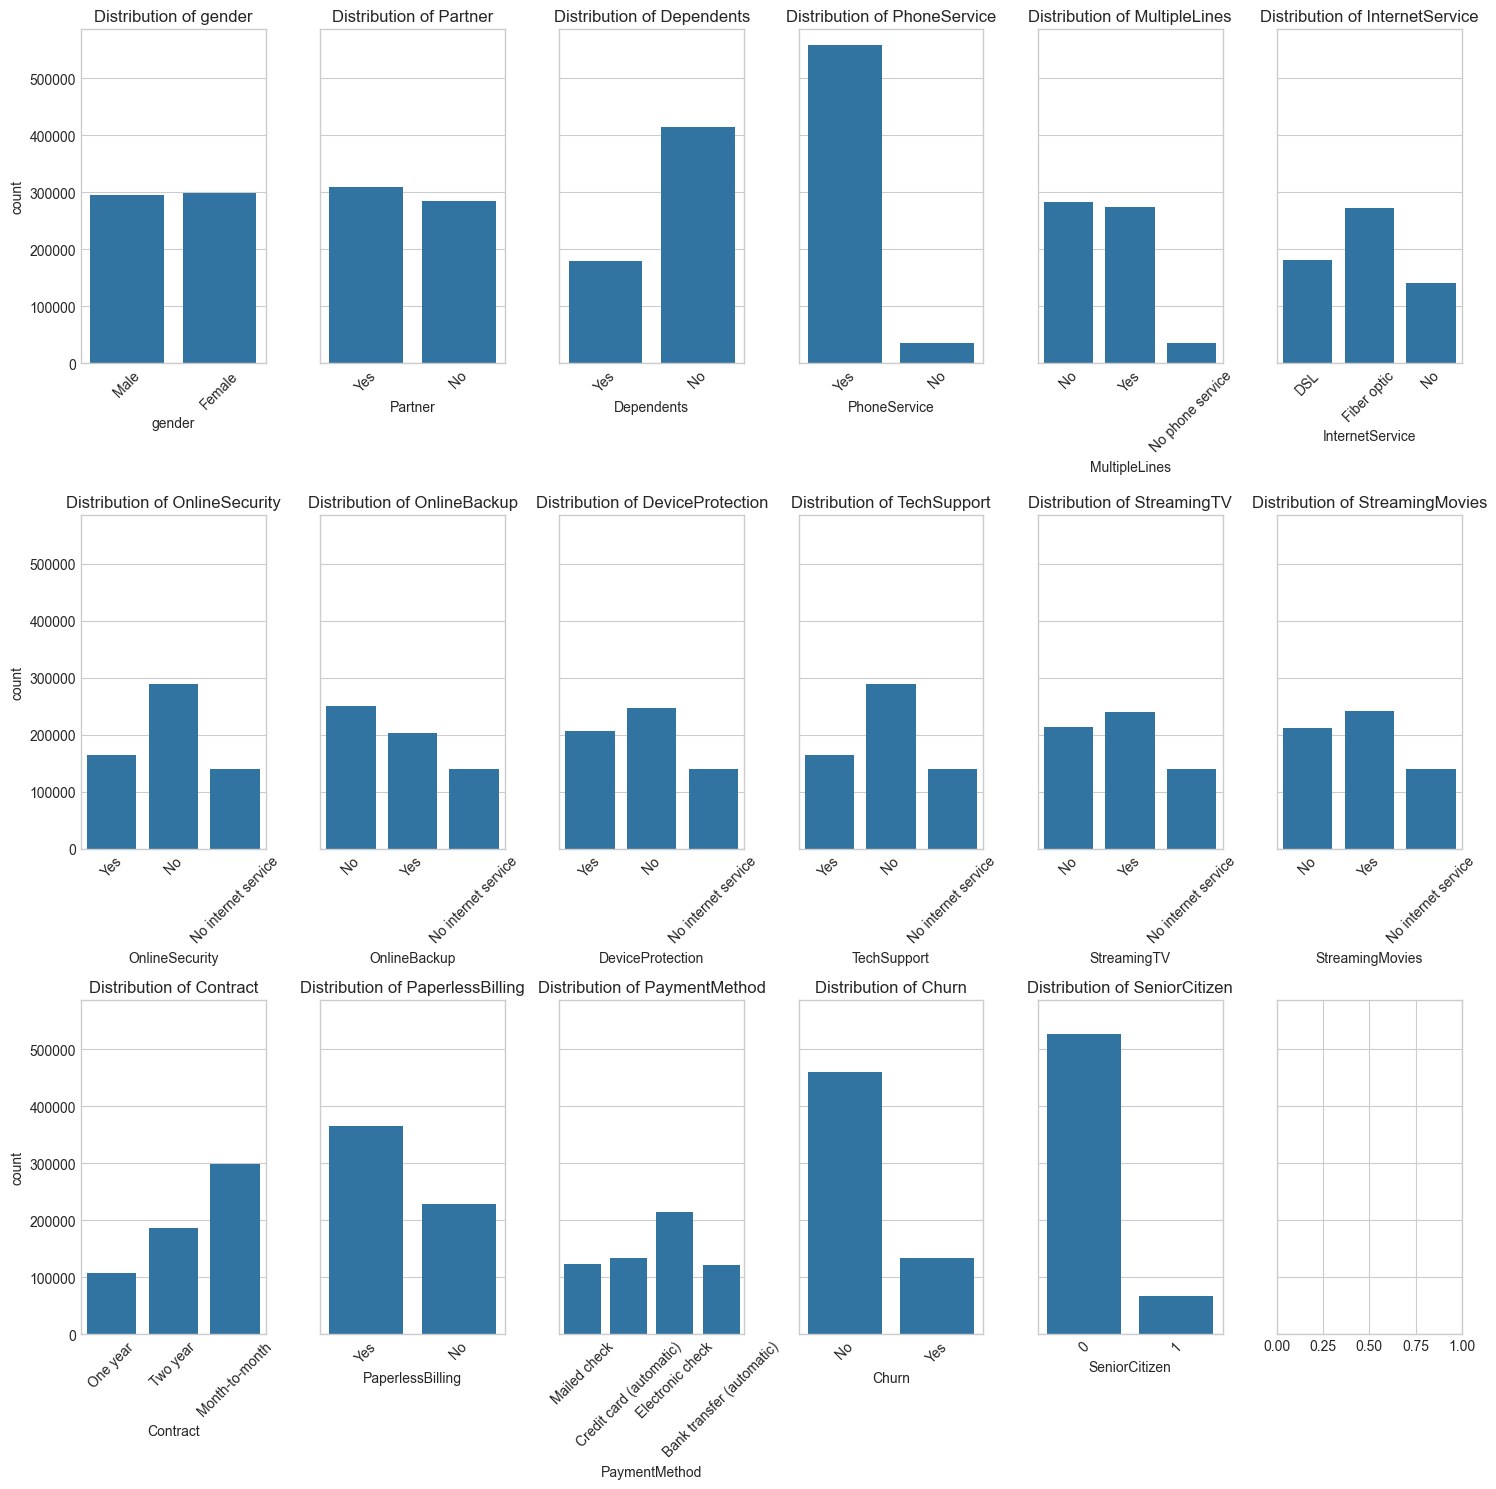

In [15]:
# カテゴリカル変数の分布を可視化 subplot 
def plot_categorical(df, column):
    plt.figure(figsize=(1, 4))
    sns.countplot(data=df, x=column)
    plt.title(f"Distribution of {column}")
    plt.xticks(rotation=45)
    plt.show()
fig, axes = plt.subplots(nrows=3, ncols=6, figsize=(15, 15), sharey=True)
for i, col in enumerate(categorical_cols):
    ax = axes[i // 6, i % 6]
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

#### 解約数は少ないことがわかったデータは不均衡といえる　モデルは解約を見逃しやすい　このことから重み付けだったり評価指標はaccuracyではなく　F1　ROC-AUC　PR-AUC　cvはStratifiedを　検討するべき

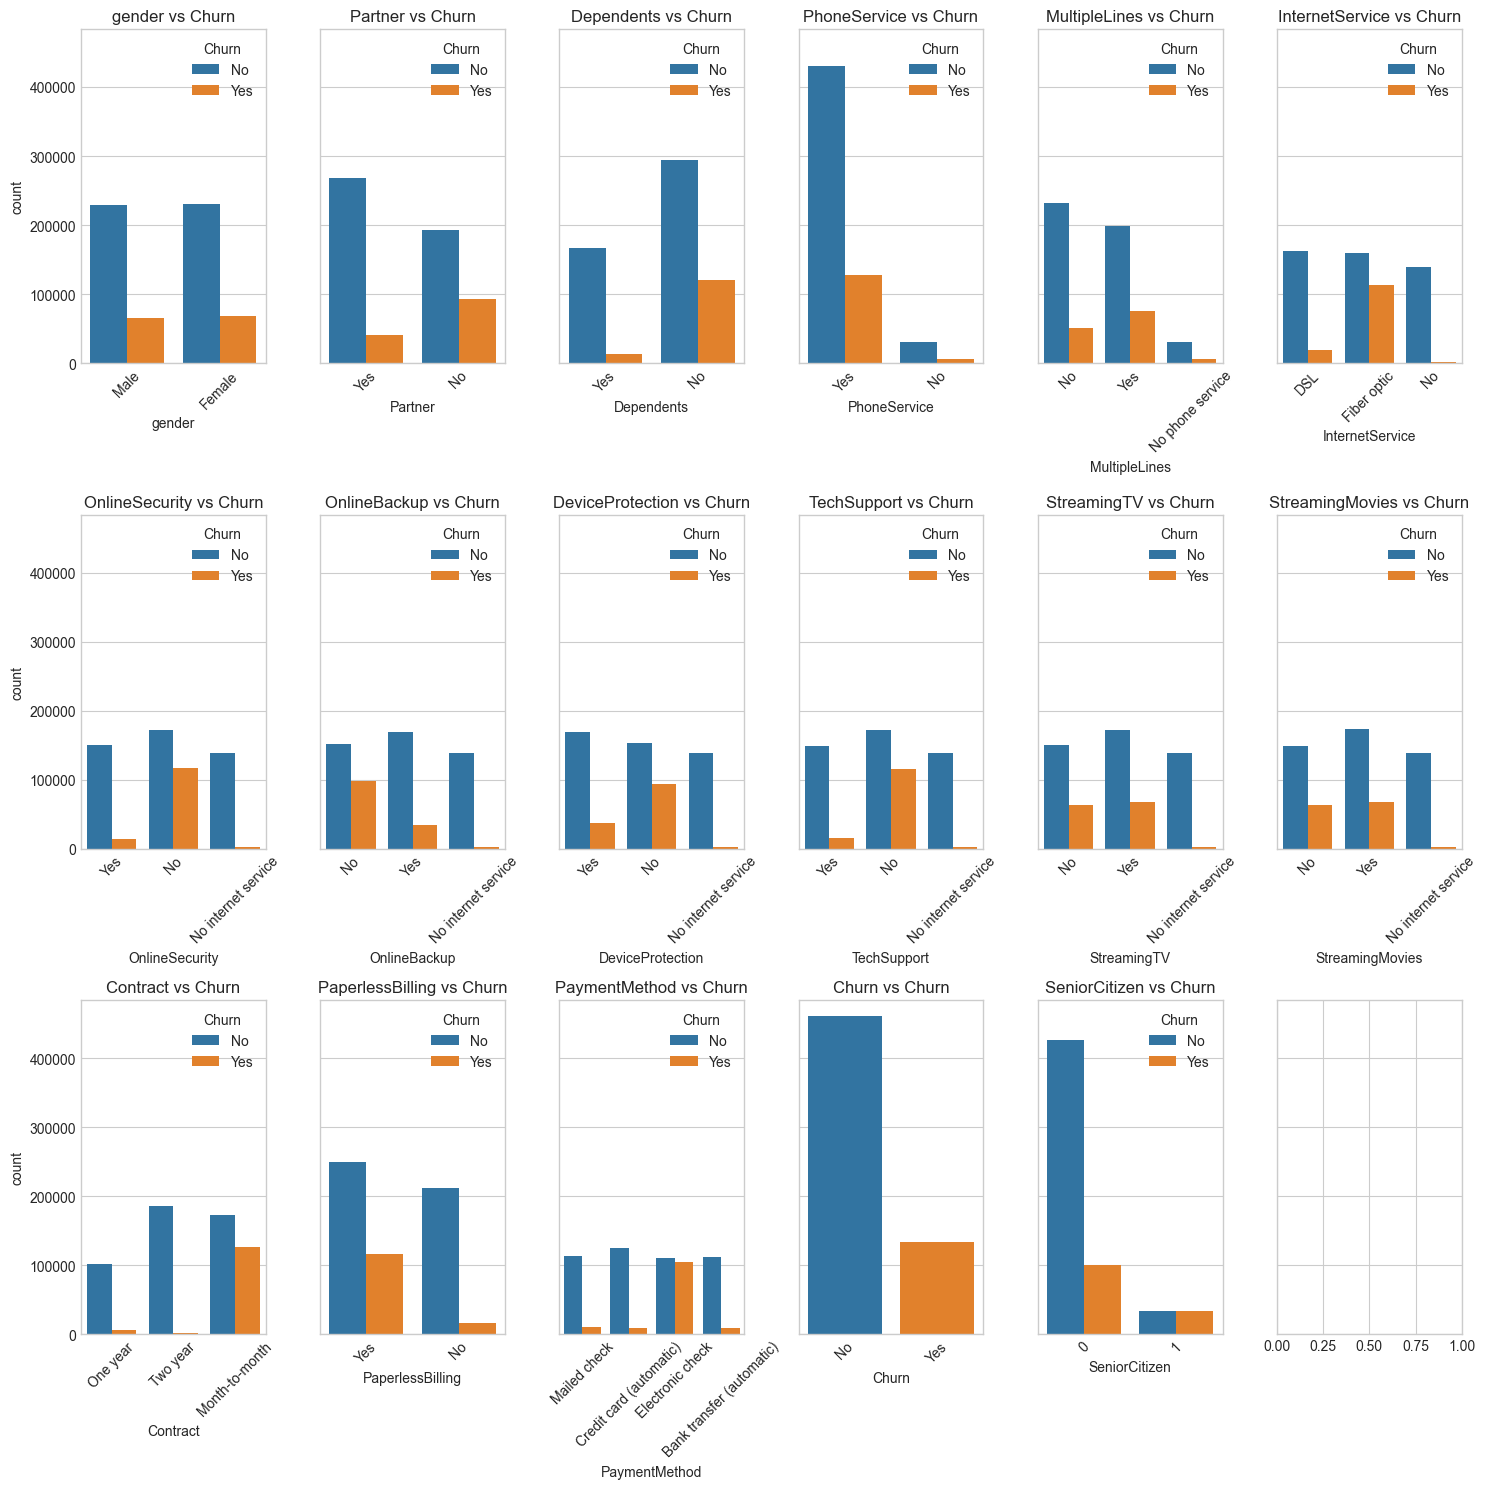

In [31]:
# カテゴリ変数と目的変数の関係を可視化
fig, axes = plt.subplots(nrows=3, ncols=6, figsize=(15, 15), sharey=True)
for i, col in enumerate(categorical_cols):
    ax = axes[i // 6, i % 6]
    sns.countplot(data=df, x=col, hue='Churn', ax=ax)
    ax.set_title(f"{col} vs Churn")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

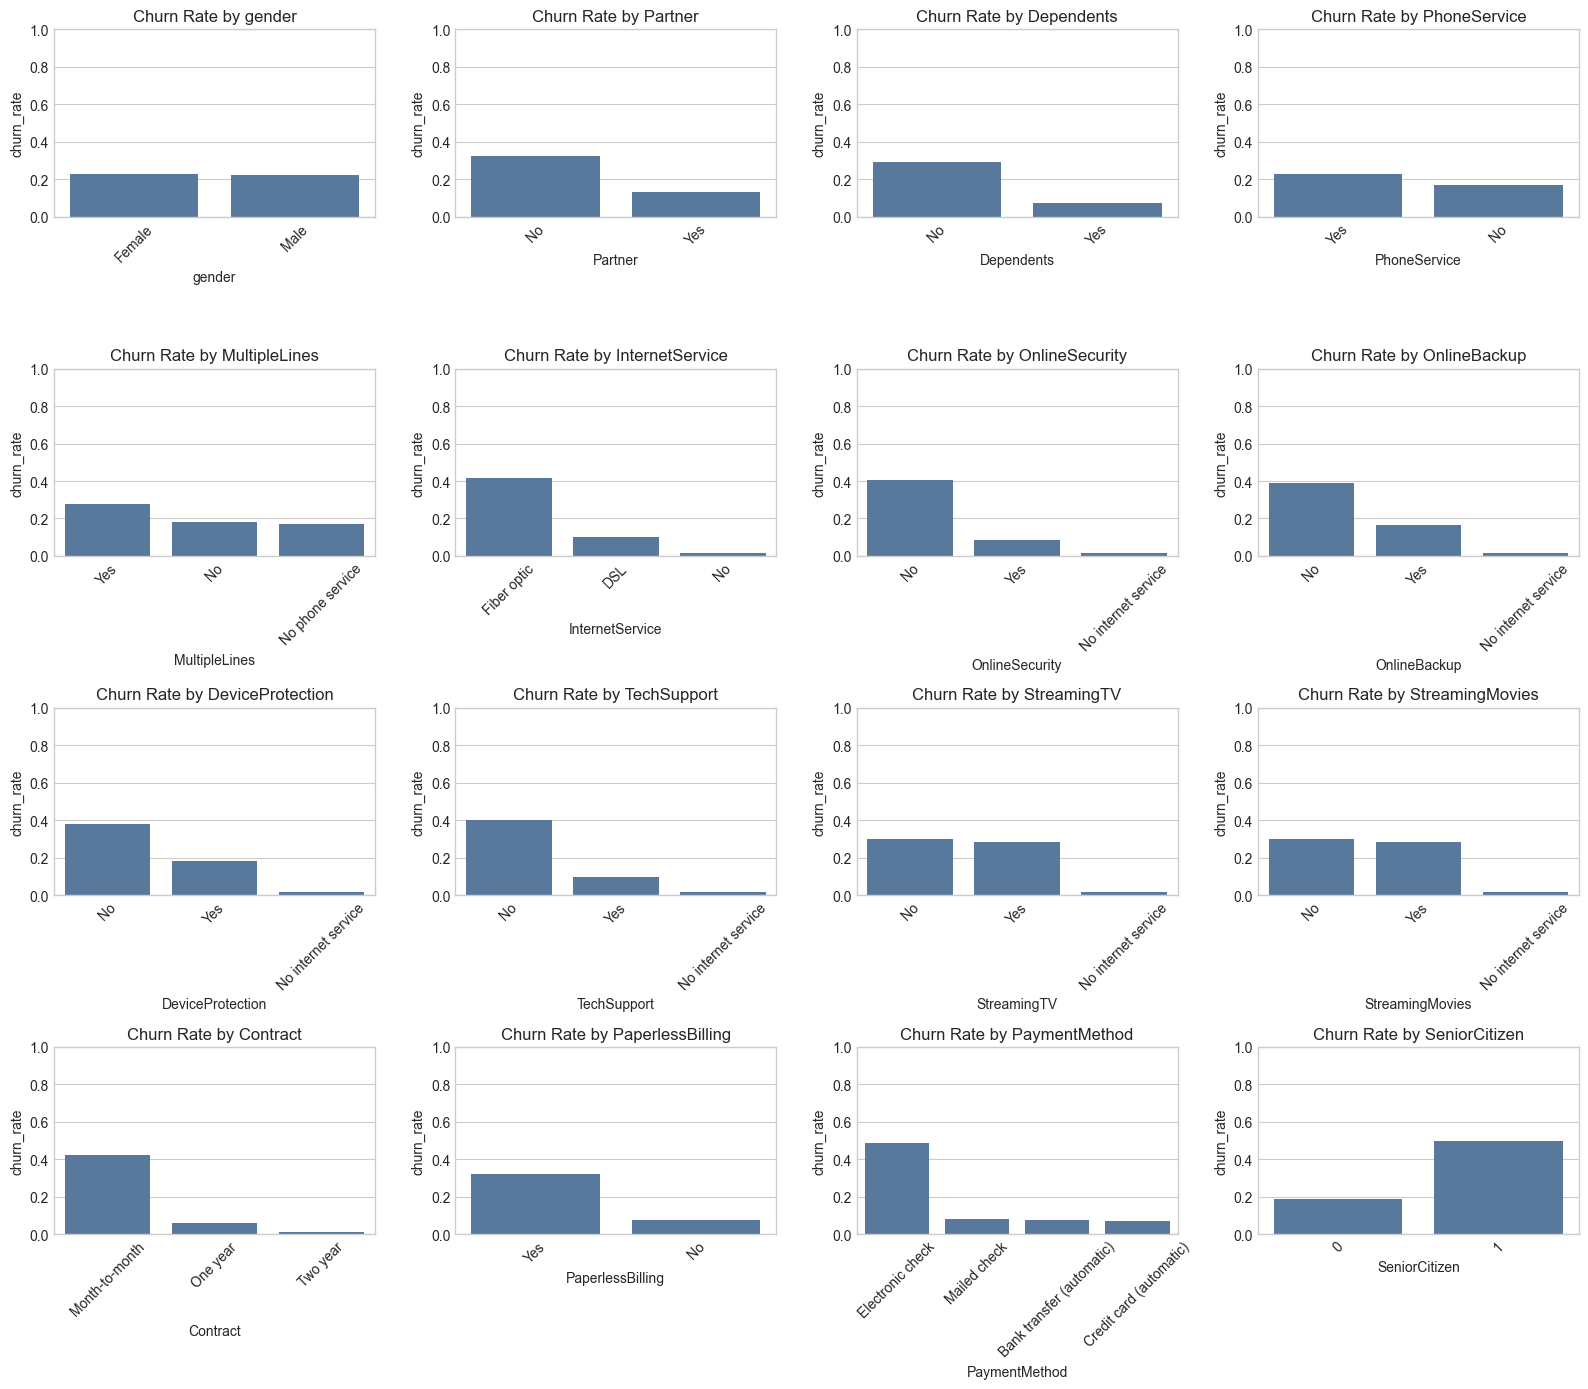

In [32]:
# カテゴリ別の解約率を可視化
plot_cols = [col for col in categorical_cols if col != "Churn"]

n_cols = 4
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(plot_cols):
    rate_df = (
        df.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean())
        .reset_index(name="churn_rate")
        .sort_values("churn_rate", ascending=False)
    )
    sns.barplot(data=rate_df, x=col, y="churn_rate", ax=axes[i], color="#4C78A8")
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis="x", rotation=45)

# 余ったサブプロットを非表示にする
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### カテゴリ別の解約率（割合）を確認
件数ではなく解約率で比較して、クラス不均衡の影響を抑えて解釈する。

## わかったこと　

契約期間が1カ月での契約では解約数が多
ペーパー請求の人は解約する確率が目視で50%くらい
支払い方法が電子小切手の人はほとんど解約している
全体的にサービスを受けてない人は解約傾向にある
シニア世代は解約傾向


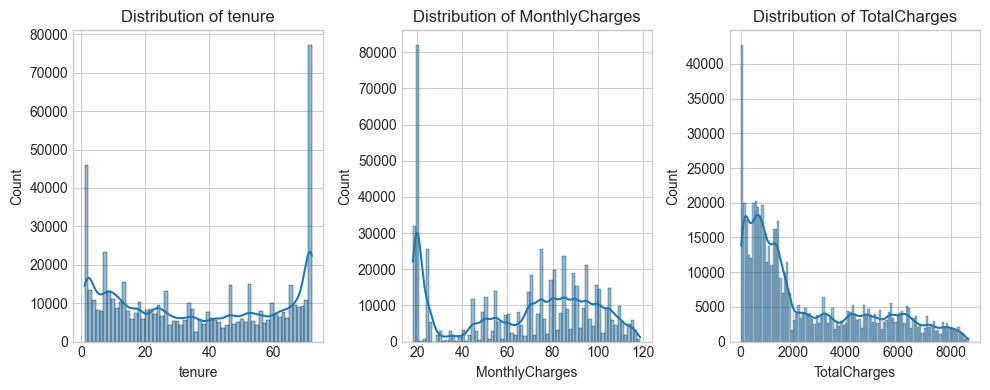

In [33]:
# 数値変数の分布を可視化
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4))
for i, col in enumerate(numerics_cols):
    ax = axes[i]
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

## 仮説
tenure（利用期間）が長いほど解約率が低い
MonthlyCharges が高いほど解約率が低い
TotalCharges が高いほど解約率が低い
を検証する

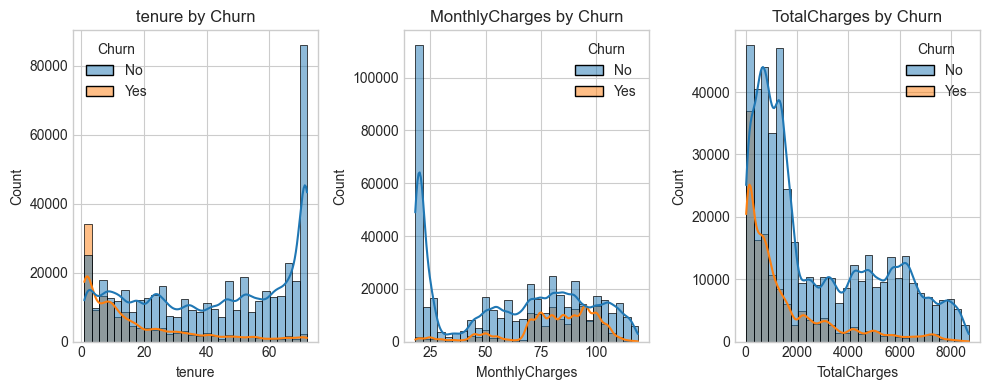

In [42]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4))
for i, col in enumerate(numerics_cols):
    ax = axes[i]
    sns.histplot(data=df, x=col, hue="Churn", bins=30, kde=True, ax=ax)
    ax.set_title(f"{col} by Churn")

plt.tight_layout()
plt.show()

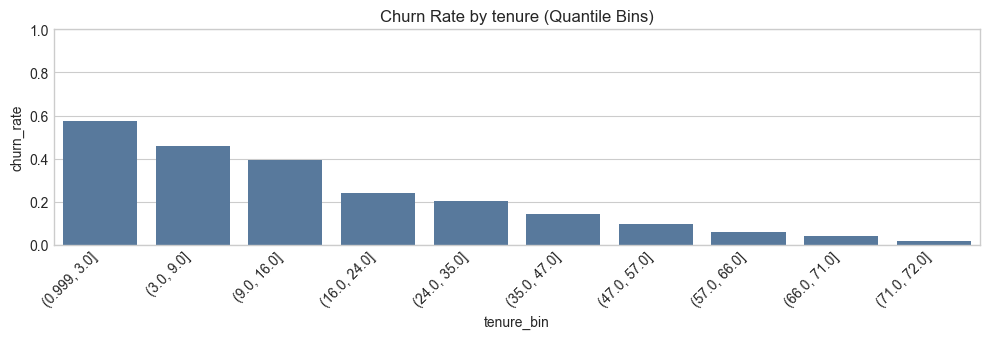

,tenure_bin,churn_rate
0,"(0.999, 3.0]",0.576347
1,"(3.0, 9.0]",0.456366
2,"(9.0, 16.0]",0.391809
3,"(16.0, 24.0]",0.240615
4,"(24.0, 35.0]",0.204125
5,"(35.0, 47.0]",0.144135
6,"(47.0, 57.0]",0.093992
7,"(57.0, 66.0]",0.057784
8,"(66.0, 71.0]",0.040979
9,"(71.0, 72.0]",0.017071


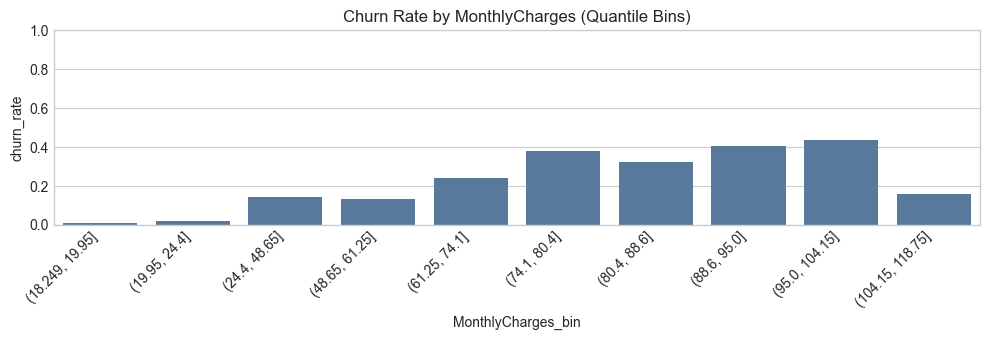

,MonthlyCharges_bin,churn_rate
0,"(18.249, 19.95]",0.012323
1,"(19.95, 24.4]",0.022441
2,"(24.4, 48.65]",0.143016
3,"(48.65, 61.25]",0.131917
4,"(61.25, 74.1]",0.239886
5,"(74.1, 80.4]",0.380933
6,"(80.4, 88.6]",0.324065
7,"(88.6, 95.0]",0.404201
8,"(95.0, 104.15]",0.434147
9,"(104.15, 118.75]",0.157901


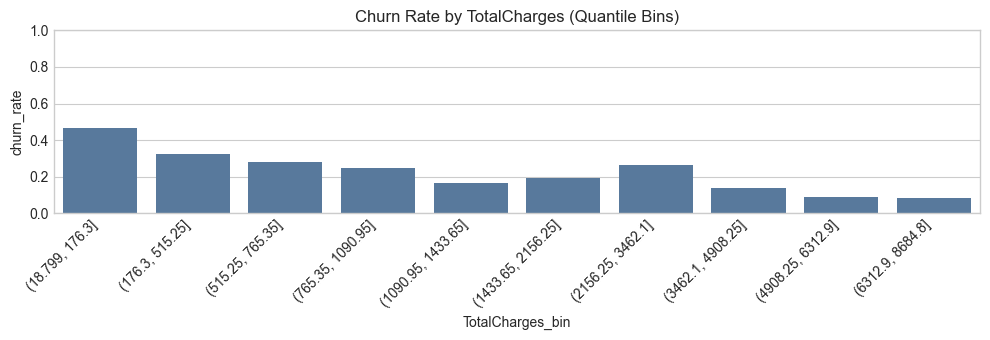

,TotalCharges_bin,churn_rate
0,"(18.799, 176.3]",0.468308
1,"(176.3, 515.25]",0.324861
2,"(515.25, 765.35]",0.279245
3,"(765.35, 1090.95]",0.249499
4,"(1090.95, 1433.65]",0.163811
5,"(1433.65, 2156.25]",0.193705
6,"(2156.25, 3462.1]",0.261982
7,"(3462.1, 4908.25]",0.137603
8,"(4908.25, 6312.9]",0.089249
9,"(6312.9, 8684.8]",0.083747


In [36]:
# 数値変数をビン分割して解約率を定量確認
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    if col not in df.columns:
        continue

    tmp = df[[col, "Churn"]].dropna().copy()
    # 分位点ベースで10ビンに分割（同値が多い場合は重複ビンを削除）
    tmp[f"{col}_bin"] = pd.qcut(tmp[col], q=10, duplicates="drop")

    rate_df = (
        tmp.groupby(f"{col}_bin")["Churn"]
        .apply(lambda x: (x == "Yes").mean())
        .reset_index(name="churn_rate")
    )

    # seaborn の型解釈エラーを避けるため、区間ラベルを文字列化して棒グラフで表示
    rate_df[f"{col}_bin"] = rate_df[f"{col}_bin"].astype(str)

    plt.figure(figsize=(10, 3.5))
    sns.barplot(data=rate_df, x=f"{col}_bin", y="churn_rate", color="#4C78A8")
    plt.title(f"Churn Rate by {col} (Quantile Bins)")
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(rate_df)

## わかったこと
- tenure が長いほど解約率は低い傾向
- TotalCharges が高いほど解約率は低い傾向
- MonthlyCharges は単調ではなく、特定レンジで解約率が高まる可能性
- 単月課金額より、継続課金（契約継続）が解約抑制に効いている可能性

<Axes: >

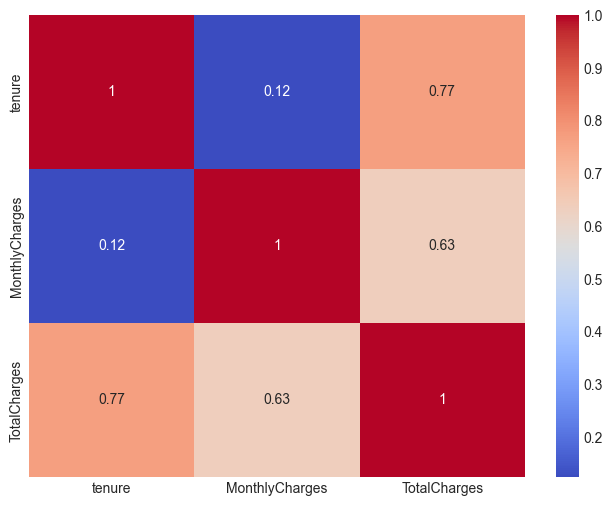

In [39]:
#　相関係数
